# Fraud Detection
**Track:** Data Analytics — Level 2, Task 3
**Objective:** Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset.

Dataset: `credit_card_transactions.csv` — 4,620 synthetic transactions with a 2.6% fraud rate, including amount, time, distance-from-home, foreign/online flags, and recent transaction frequency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

df = pd.read_csv("credit_card_transactions.csv")
df.head()

,TransactionID,Amount,Hour,TransactionsLast24h,DistanceFromHome,IsForeignTxn,IsOnline,Class
0,1,6.21,17,3,3.1,0,1,0
1,2,13.85,9,1,13.9,0,0,0
2,3,29.65,19,5,9.8,0,1,0
3,4,547.33,0,13,177.5,1,1,1
4,5,1.44,17,3,4.4,0,1,0


## 1. Class Imbalance Analysis

Fraudulent transactions: 120 out of 4620 (2.60%)


/tmp/ipykernel_554/2553093261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette=["#4C72B0","#C44E52"])


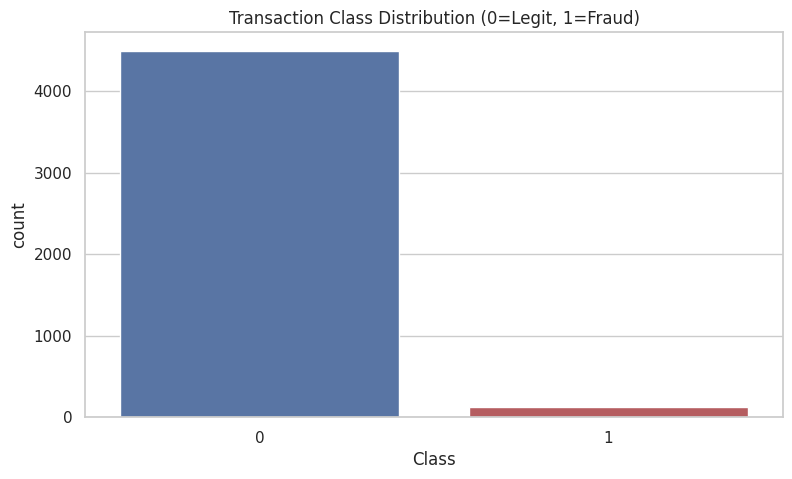

In [2]:
fraud_rate = df["Class"].mean() * 100
print(f"Fraudulent transactions: {df['Class'].sum()} out of {len(df)} ({fraud_rate:.2f}%)")

plt.figure()
sns.countplot(x="Class", data=df, palette=["#4C72B0","#C44E52"])
plt.title("Transaction Class Distribution (0=Legit, 1=Fraud)")
plt.show()

## 2. EDA — Amount & Time Patterns

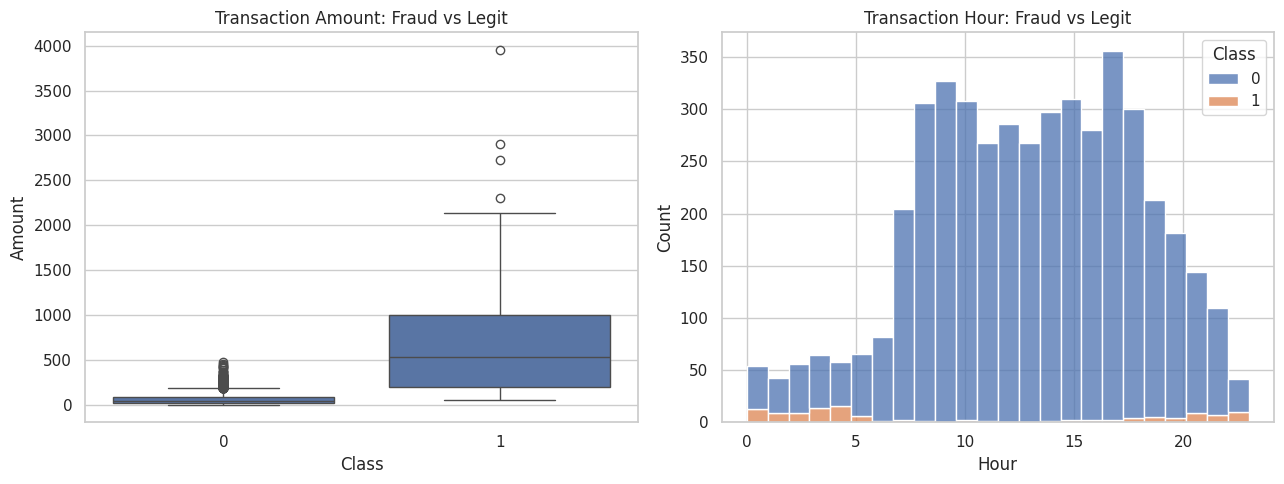

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0])
axes[0].set_title("Transaction Amount: Fraud vs Legit")

sns.histplot(data=df, x="Hour", hue="Class", bins=24, multiple="stack", ax=axes[1])
axes[1].set_title("Transaction Hour: Fraud vs Legit")
plt.tight_layout()
plt.show()

**Observation:** Fraudulent transactions tend to involve much higher amounts and cluster more heavily in late-night/early-morning hours compared to legitimate ones.

## 3. Why Accuracy Is Misleading Here

**Discussion:** With only ~2.6% of transactions being fraudulent, a model that predicts "not fraud" for *every single transaction* would still achieve ~97.4% accuracy while catching zero fraud.
Accuracy rewards majority-class correctness and completely hides how well the model finds the rare, costly fraud cases — which is the entire point of this system.
That's why we must rely on **Precision, Recall, F1, and AUC-ROC** instead.

## 4. Handle Class Imbalance with SMOTE

In [4]:
X = df.drop(columns=["TransactionID", "Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 3600, 1: 96}
After SMOTE: {0: 3600, 1: 3600}


## 5. Train 2 Models

In [5]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

print("Models trained.")

Models trained.


## 6. Evaluation — Precision, Recall, F1, AUC-ROC

In [6]:
for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf)]:
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:,1]
    print(f"--- {name} ---")
    print(f"Precision: {precision_score(y_test, pred):.3f}")
    print(f"Recall:    {recall_score(y_test, pred):.3f}")
    print(f"F1-score:  {f1_score(y_test, pred):.3f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, proba):.3f}")
    print()

--- Logistic Regression ---
Precision: 0.697
Recall:    0.958
F1-score:  0.807
AUC-ROC:   0.992

--- Random Forest ---
Precision: 0.952
Recall:    0.833
F1-score:  0.889
AUC-ROC:   0.975



## 7. ROC Curves

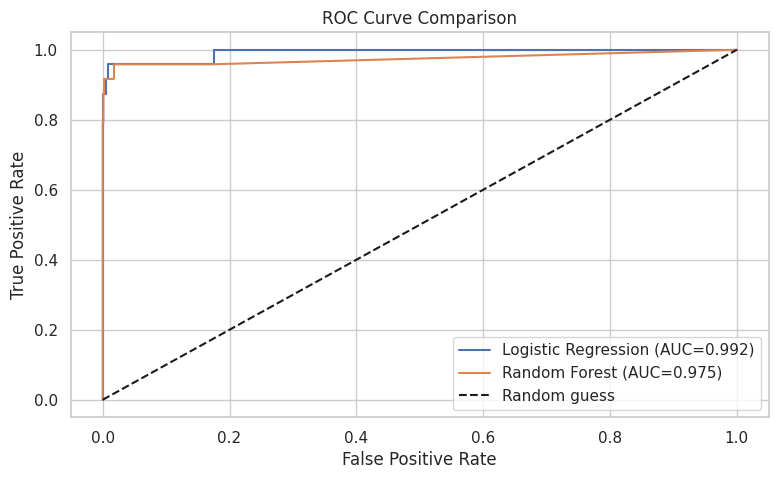

In [7]:
plt.figure()
for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf)]:
    proba = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

plt.plot([0,1],[0,1],'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 8. Confusion Matrices

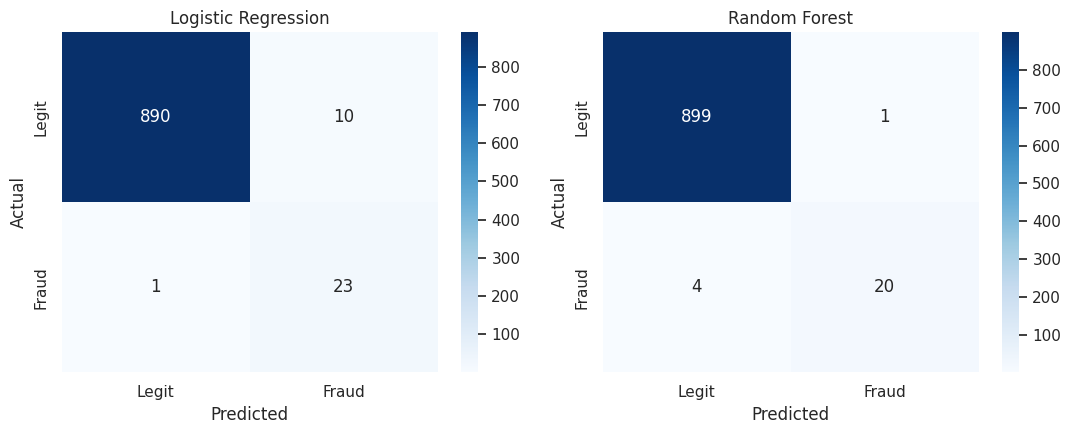

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, (name, model) in zip(axes, [("Logistic Regression", log_reg), ("Random Forest", rf)]):
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Which Metric Matters Most: Recall vs Precision

**Discussion:** In fraud detection, **missing a real fraud case (false negative)** is usually far more costly than **flagging a legitimate transaction for review (false positive)** —
a missed fraud means direct financial loss, while a false alarm just means an extra verification step for the customer.
This means **Recall** (catching as many actual frauds as possible) is generally prioritized over Precision, even though this raises the number of false alarms analysts must review.
In practice, teams often pick an operating threshold that maximizes Recall subject to a maximum tolerable false-positive rate.

## 10. Feature Importance

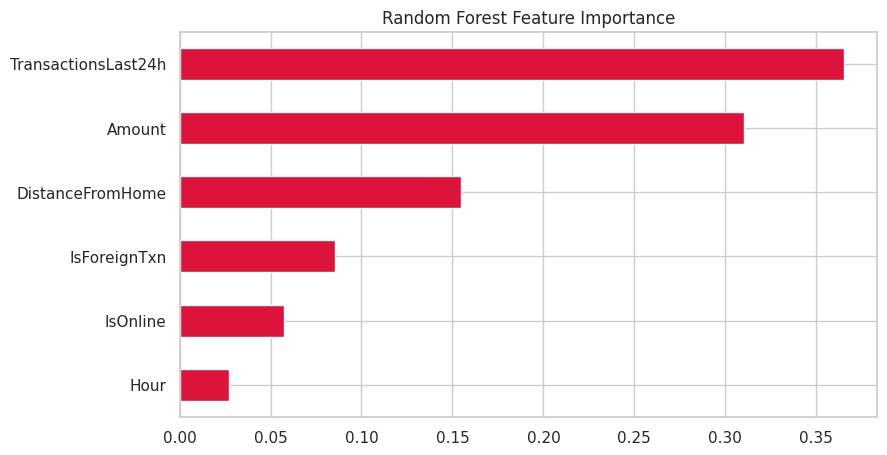

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure()
importances.plot(kind="barh", color="crimson")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

**Observation:** `Amount`, `DistanceFromHome`, and `Hour` are typically the strongest fraud indicators — consistent with the EDA patterns observed earlier.

## 11. Scalability Discussion

**How would this scale to 1 million transactions/hour?**
- Feature computation (rolling counts, distance-from-home) would need a streaming architecture (e.g. Kafka + a feature store) rather than batch pandas processing.
- Random Forest inference is fast per-transaction but scoring 1M/hour still needs horizontal scaling — deploying the trained model behind a load-balanced low-latency API, or using a lighter model (e.g. Logistic Regression or a distilled tree ensemble) if p99 latency becomes the bottleneck.
- The model should be retrained periodically (e.g. weekly) as fraud patterns evolve ("concept drift"), with monitoring on live precision/recall against confirmed fraud labels.
- A tiered system is common in practice: a fast, cheap model flags likely fraud in real time, and a slower, more thorough second-stage model or human review handles the flagged subset.

## Conclusion
Both models substantially outperform random guessing, with Random Forest generally achieving a higher AUC-ROC and better balance of precision/recall after SMOTE resampling corrected the severe class imbalance.
For production, Recall should be weighted heavily given the asymmetric cost of missed fraud, and the system would need a streaming architecture to operate at real-world transaction volumes.